# Modelado predictivo para predecir el precio de alquiler de un departamento en Lima con XGBoost

### 1. Instalacion y verificacion de permisos

**1.1. instalacion e importacion de las librerias**

In [46]:
from sagemaker import get_execution_role
import boto3

import pandas as pd
import numpy as np
from datetime import datetime

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV

from sagemaker.sklearn.estimator import SKLearn
from sagemaker.sklearn.model import SKLearnModel

from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_percentage_error

from utils.utils import configurar_logger
from utils.storage import listar_archivos_s3
from utils.storage import descargar_archivo_s3
from utils.storage import upload_to_s3
from utils.storage import crear_folder

import joblib

**1.2. rol y permisos**

Veamos cual es el rol actual que usaremos en el notebook, no podemos ver que politicas tiene porque este rol no tiene permisos para eso, sin embargo debemos asegurarnos que tiene los permisos adecuados para usar otros servicios de Sage Maker.

In [2]:
iam_client = boto3.client('iam')
role = get_execution_role()
role_name = role.split('/')[-1]
print(f"Rol actual : {role_name}")

Rol actual : AmazonSageMaker-ExecutionRole-20250701T161934


**1.3. Creacion del folder en un bucket S3**

In [6]:
timestamp = str(datetime.now())
ruta_folder = crear_folder(timestamp)

### 2. Analisis

In [11]:
logger = configurar_logger(f"logs/logs_{timestamp}.log")

In [12]:
archivos = listar_archivos_s3('data')
if not archivos:
    logger.error("Error, no existen archivos en el folder")
    exit
archivo_mas_reciente = max(archivos, key = lambda x: x['LastModified'])
ruta_archivo = descargar_archivo_s3(archivo_mas_reciente['Key'],f'data/data_{timestamp}.csv')

Archivo descargado: s3://proyecto-analisis-lima/data/data_csv_data_hipotesis.csv → data/data_2025-07-03 19:44:27.203292.csv


In [13]:
data = pd.read_csv(ruta_archivo)
data.drop(columns=['Unnamed: 0','precision','type','precioxm2','direccion','fecha_publicacion','lima_top',
                'precioxm2_log','precio_log','area_log','banos/dormitorio','descripcion','distrito_clase'],inplace=True)
data.head()

,latitud,dormitorios,longitud,banos,area,precio,distrito,antiguedad_categoria
0,-12.139912,3.0,-77.018606,2.0,77.0,2960.0,barranco,Grupo 2
1,-12.139272,2.0,-77.021154,2.0,96.0,2250.0,barranco,Grupo 1
2,-12.139555,1.0,-77.023879,1.0,40.0,2000.0,barranco,Grupo 3
3,-12.138541,3.0,-77.017627,2.0,80.0,2974.0,barranco,Grupo 3
4,-12.138338,2.0,-77.025239,1.0,70.0,2800.0,barranco,Grupo 2


In [14]:
data.isnull().mean().sort_values(ascending=False)

latitud                 0.0
dormitorios             0.0
longitud                0.0
banos                   0.0
area                    0.0
precio                  0.0
distrito                0.0
antiguedad_categoria    0.0
dtype: float64

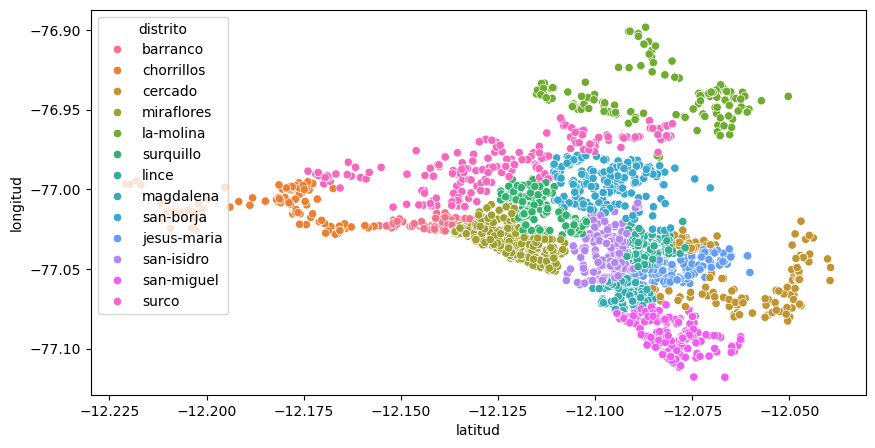

In [15]:
plt.figure(figsize=(10,5))
sns.scatterplot(data=data,x='latitud',y='longitud',hue='distrito')
plt.show()

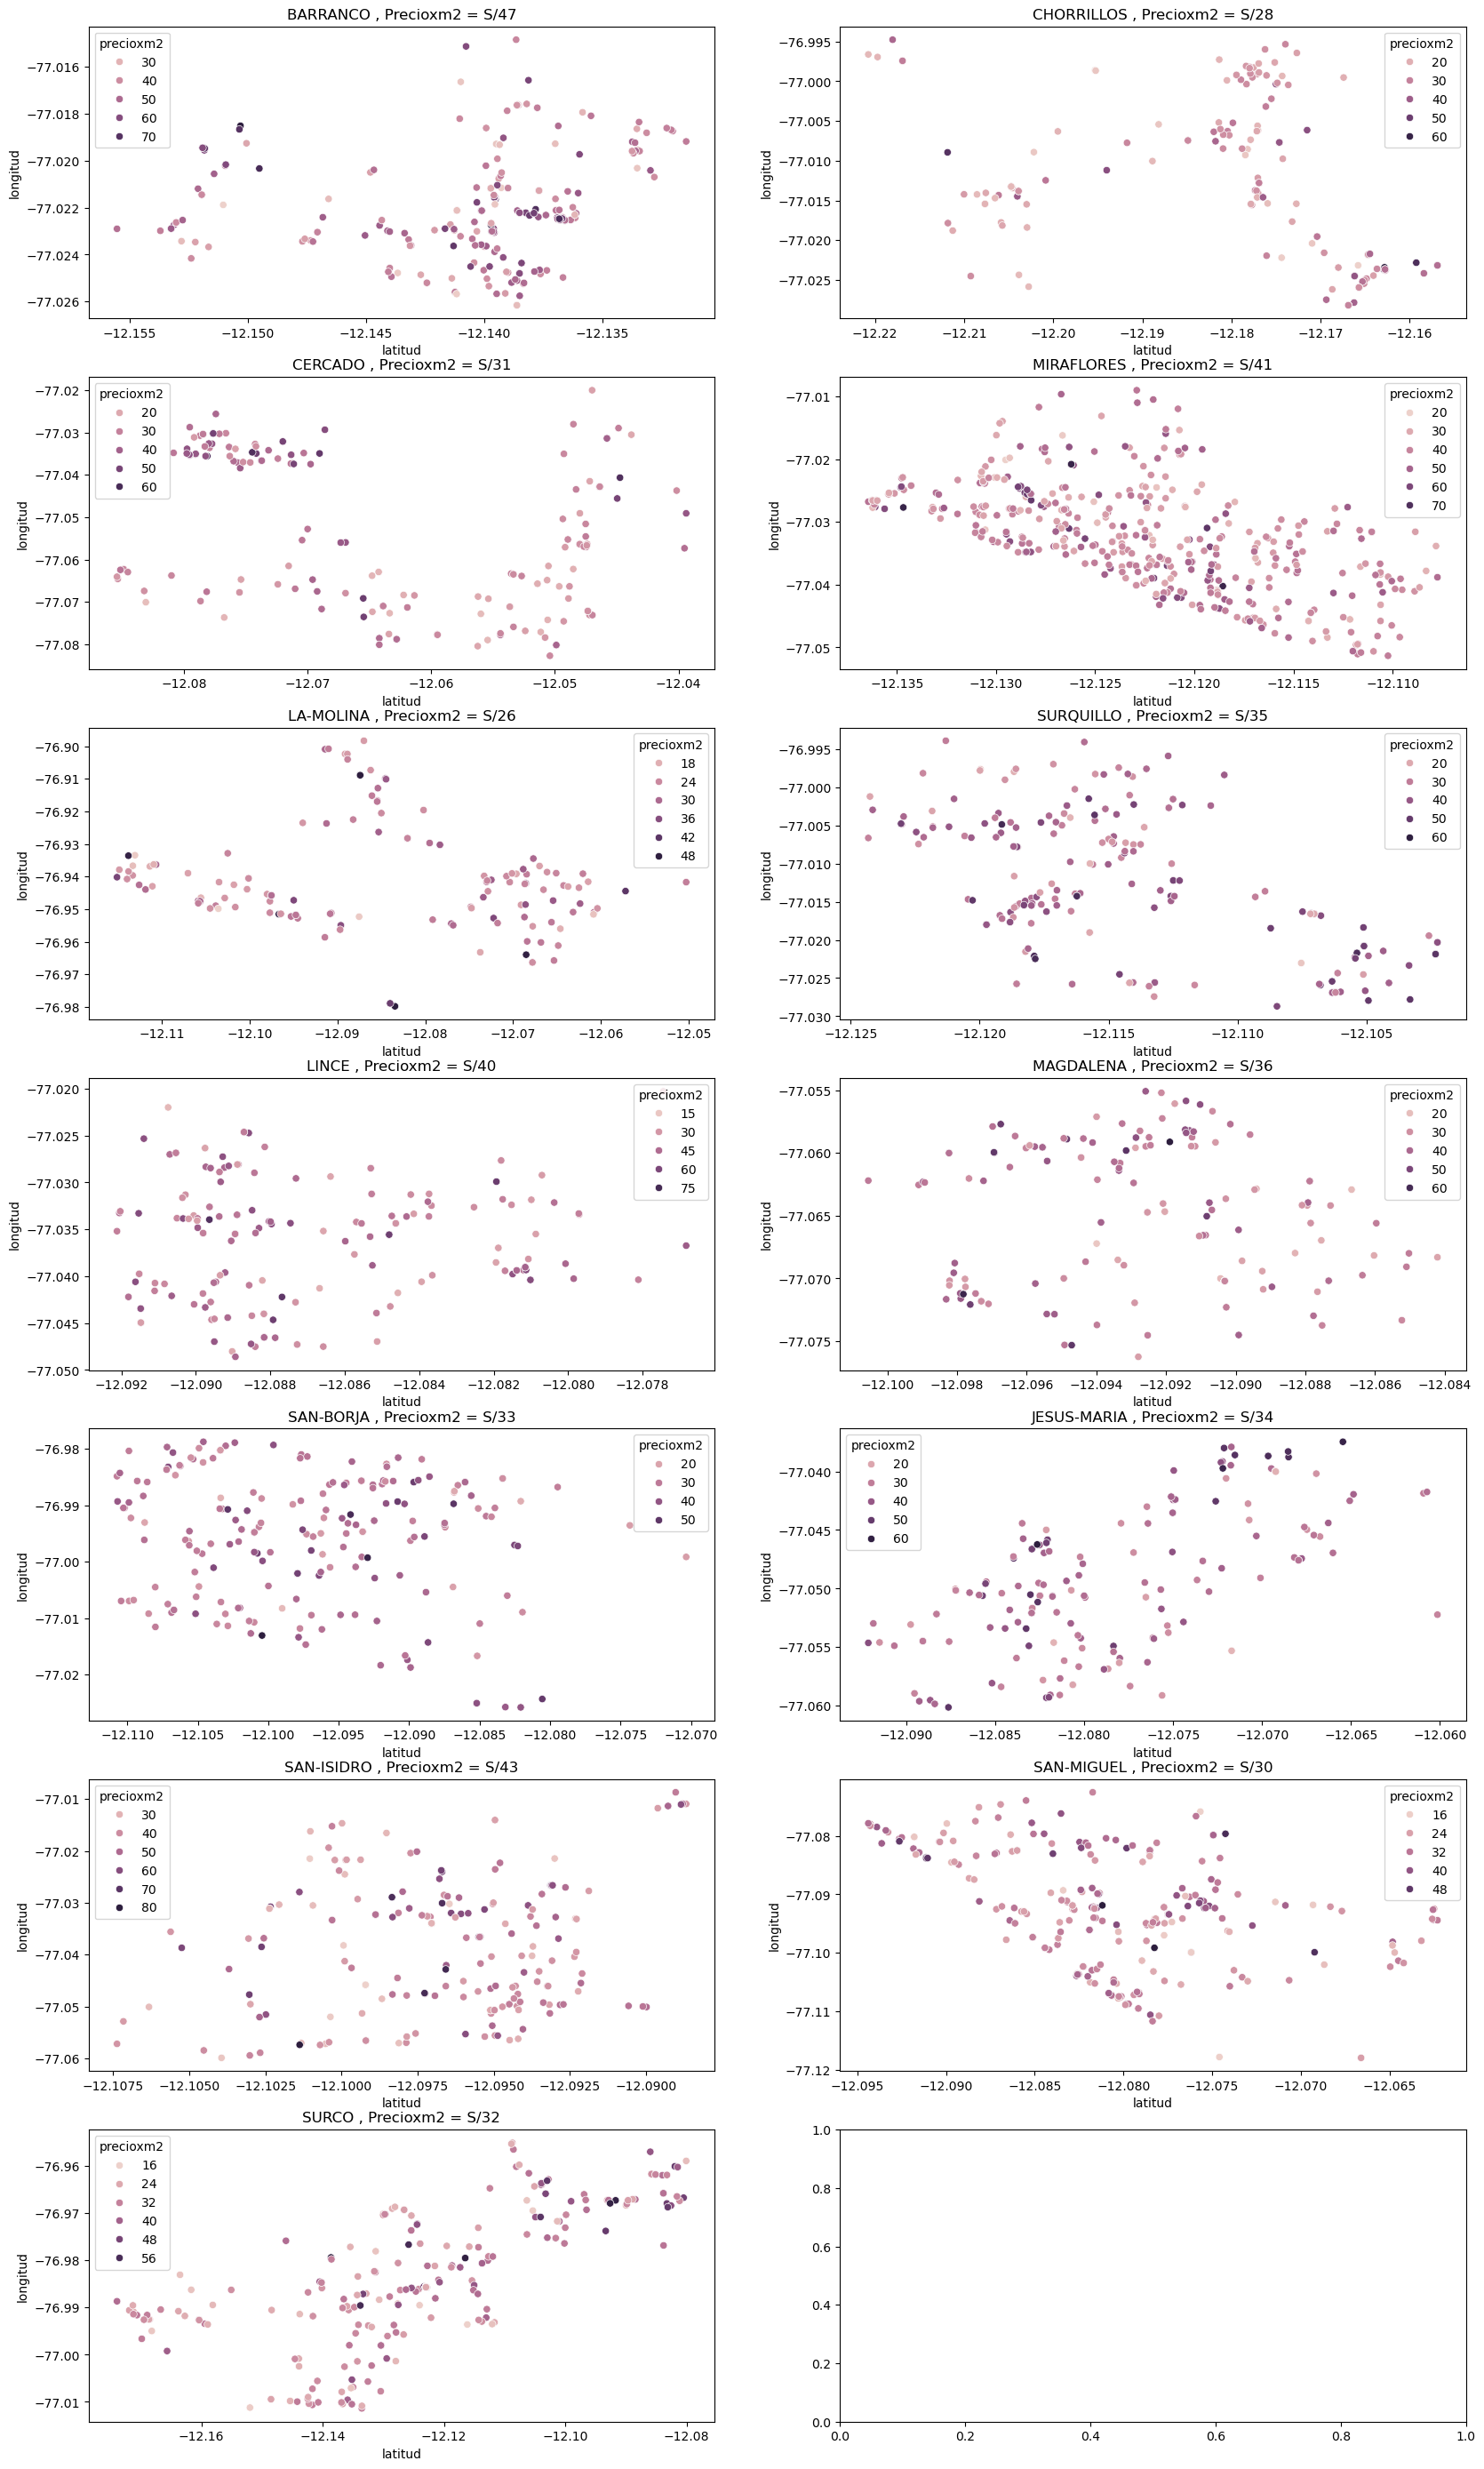

In [16]:
df_temp = data.copy()
df_temp['precioxm2'] = df_temp['precio']/df_temp['area']
fig, ax = plt.subplots(7, 2, figsize=(20, 35))
for i,x in enumerate(data['distrito'].unique()):
    f,c = i//2,i%2
    df_dist = df_temp.query(f"distrito=='{x}'")
    sns.scatterplot(data=df_dist,x='latitud',y='longitud',hue='precioxm2',ax=ax[f,c])
    ax[f,c].set_title(f"{x.upper()} , Precioxm2 = S/{df_dist['precioxm2'].mean():.0f}")
fig.show()

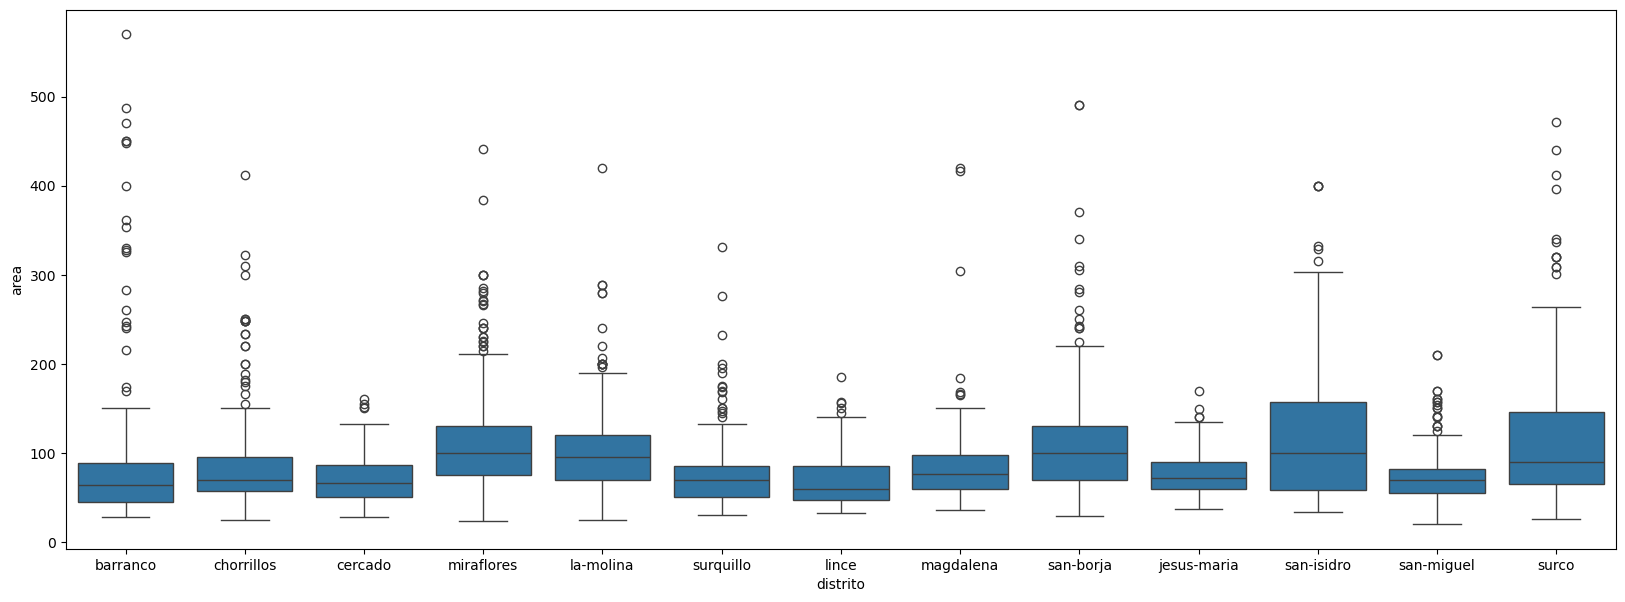

In [17]:
plt.figure(figsize=(20,7))
sns.boxplot(data=data,x='distrito',y='area')
plt.show()

<Axes: >

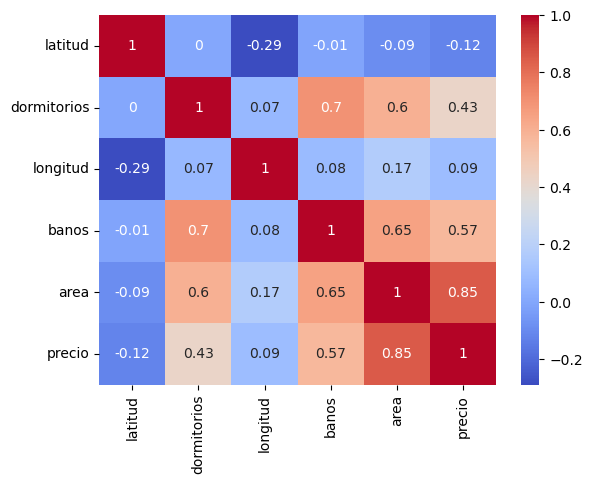

In [18]:
corr = np.round(data.select_dtypes(include=('int','float')).corr(),2)
sns.heatmap(corr,annot=True,cmap='coolwarm')

### 3. Creacion del custom job

In [42]:
train, test = np.split(data,[int(0.8*data.shape[0])])

train.to_csv("data/train.csv",index=False)
test.to_csv("data/test.csv",index=False)

upload_to_s3("data/train.csv",ruta_folder+"data/train.csv")
upload_to_s3("data/test.csv",ruta_folder+"data/test.csv")

/home/ec2-user/anaconda3/envs/pytorch_p310/lib/python3.10/site-packages/numpy/core/fromnumeric.py:59: FutureWarning: 'DataFrame.swapaxes' is deprecated and will be removed in a future version. Please use 'DataFrame.transpose' instead.
  return bound(*args, **kwds)


True

In [43]:
sklearn_estimator = SKLearn(
    entry_point="train.py",
    source_dir="src_train",
    role=role,
    instance_count=1,
    instance_type="ml.m5.large",
    framework_version="1.2-1",
    py_version="py3",
    dependencies=["src_train/requirements.txt"],
    output_path="s3://proyecto-analisis-lima/"+ruta_folder+"modelo/",
    base_job_name="xgb-gridsearch"
)

In [44]:
sklearn_estimator.fit({"train": "s3://proyecto-analisis-lima/"+ruta_folder+"data/"})

INFO:sagemaker.telemetry.telemetry_logging:SageMaker Python SDK will collect telemetry to help us better understand our user's needs, diagnose issues, and deliver additional features.
To opt out of telemetry, please disable via TelemetryOptOut parameter in SDK defaults config. For more information, refer to https://sagemaker.readthedocs.io/en/stable/overview.html#configuring-and-using-defaults-with-the-sagemaker-python-sdk.
INFO:sagemaker:Creating training-job with name: xgb-gridsearch-2025-07-03-22-24-56-711


2025-07-03 22:24:58 Starting - Starting the training job...
2025-07-03 22:25:12 Starting - Preparing the instances for training...
2025-07-03 22:26:02 Downloading - Downloading the training image......
2025-07-03 22:27:03 Training - Training image download completed. Training in progress..2025-07-03 22:27:04,114 sagemaker-containers INFO     Imported framework sagemaker_sklearn_container.training
2025-07-03 22:27:04,117 sagemaker-training-toolkit INFO     No GPUs detected (normal if no gpus installed)
2025-07-03 22:27:04,120 sagemaker-training-toolkit INFO     No Neurons detected (normal if no neurons installed)
2025-07-03 22:27:04,135 sagemaker_sklearn_container.training INFO     Invoking user training script.
2025-07-03 22:27:04,366 sagemaker-training-toolkit INFO     Installing dependencies from requirements.txt
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.6/9.6 MB 133.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 200.3/200.3 MB 169.5 MB/s eta 0:00:00
   ━━━━━━━━━━━

### 4. Creacion del endpoint en Sage Maker

In [64]:
model = SKLearnModel(
    model_data=sklearn_estimator.model_data,
    role=role,
    entry_point="serve.py",
    source_dir="src_endpoint",
    dependencies=["src_endpoint/requirements.txt"],
    framework_version="1.2-1",
    py_version="py3"
)

In [65]:
predictor = model.deploy(
    initial_instance_count=1,
    instance_type="ml.m5.large",
    endpoint_name="xgb-endpoint-v4",
    vpc_config={
        'Subnets': ['subnet-0ec70977100faa6e0'],
        'SecurityGroupIds': ['sg-0c4f3f43ab85d2e3f']
    }
)

INFO:sagemaker:Creating model with name: sagemaker-scikit-learn-2025-07-04-00-14-46-644
INFO:sagemaker:Creating endpoint-config with name xgb-endpoint-v4
INFO:sagemaker:Creating endpoint with name xgb-endpoint-v4


-------!

Ahora probamos el endpoint Sage maker

In [70]:
runtime = boto3.client("sagemaker-runtime")

# Simula una entrada como CSV (con los nombres de columnas que espera tu modelo)
payload = "latitud,dormitorios,longitud,banos,area,distrito,antiguedad_categoria\n-12.139912,3.0,-77.018606,2.0,77.0,barranco,Grupo 2"

response = runtime.invoke_endpoint(
    EndpointName="xgb-endpoint-v4",
    ContentType="text/csv",
    Accept="text/csv",
    Body=payload
)
print(response["Body"].read().decode("utf-8"))

2949.007080078125


### 5. Creacion de Lambda

In [82]:
lambda_client = boto3.client('lambda')

In [83]:
with open('src_lambda/lambda_function.zip', 'rb') as f:
    zipped_code = f.read()

In [84]:
response = lambda_client.create_function(
    FunctionName='invokeSageMakerFromLambda',
    Runtime='python3.10',
    Role='arn:aws:iam::042298216868:role/LambdaSageMakerInvokeRole',
    Handler='lambda_function.lambda_handler',
    Code={'ZipFile': zipped_code},
    Timeout=30,
    MemorySize=128,
    VpcConfig={
        'SubnetIds': ['subnet-0ec70977100faa6e0'],
        'SecurityGroupIds': ['sg-002f00a503027745e']
    }
)

print("Lambda creada:", response['FunctionArn'])


Lambda creada: arn:aws:lambda:us-east-1:042298216868:function:invokeSageMakerFromLambda
